# Q2: Phân tích tác động của tham số Support, Confidence, Lift

## Mục đích
Khám phá cách các tham số **Support**, **Confidence** và **Lift** ảnh hưởng đến kết quả của Apriori Algorithm trong phân tích luật kết hợp (Association Rules Mining)

## Định nghĩa các tham số

| Tham số | Định nghĩa | Ảnh hưởng |
|---------|-----------|---------|
| **Support** | Tần suất xuất hiện của itemset trong toàn bộ giao dịch | Giảm → Nhiều rule, tăng → Ít rule nhưng quan trọng hơn |
| **Confidence** | P(B\|A) = Xác suất mua B khi mua A | Cao → Rule chặt chẽ hơn, thấp → Rule lỏng lẻo |
| **Lift** | Tỷ lệ P(A,B) / (P(A) * P(B)) | > 1 = Mua cùng ↑, < 1 = Mua cùng ↓, = 1 = Độc lập |

## Phần 1: Chuẩn bị dữ liệu

In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Setup path
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    project_root = os.path.abspath("..")
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

from apriori_library import DataCleaner, BasketPreparer, AssociationRulesMiner, DataVisualizer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Setup hoàn tất")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Setup hoàn tất


In [4]:
# Tải và làm sạch dữ liệu
DATA_PATH = os.path.join(project_root, "data/raw/online_retail.csv")
OUTPUT_DIR = os.path.join(project_root, "data/processed")

cleaner = DataCleaner(DATA_PATH)
df = cleaner.load_data()
df_clean = cleaner.clean_data()

print(f"\n✓ Dữ liệu gốc: {df.shape[0]:,} giao dịch")
print(f"✓ Dữ liệu sạch: {df_clean.shape[0]:,} giao dịch")
print(f"✓ Khách hàng UK: {df_clean['CustomerID'].nunique():,} khách")

Kích thước dữ liệu: (541909, 8)
Số bản ghi: 541,909

✓ Dữ liệu gốc: 541,909 giao dịch
✓ Dữ liệu sạch: 485,123 giao dịch
✓ Khách hàng UK: 3,921 khách


In [6]:
# Chuẩn bị dữ liệu basket format
basket_prep = BasketPreparer(df_clean)
basket = basket_prep.create_basket()
basket_bool = basket_prep.encode_basket(threshold=1)

# Lọc sản phẩm xuất hiện ít nhất 5 lần
min_product_count = 5
product_counts = basket_bool.sum()
popular_products = product_counts[product_counts >= min_product_count].index
basket_bool = basket_bool[popular_products]

print(f"✓ Basket bool shape: {basket_bool.shape}")
print(f"✓ Số khách hàng (giao dịch): {basket_bool.shape[0]}")
print(f"✓ Số sản phẩm (sau lọc): {basket_bool.shape[1]}")
print(f"✓ Density: {(basket_bool.sum().sum() / (basket_bool.shape[0] * basket_bool.shape[1]) * 100):.2f}%")

✓ Basket bool shape: (18019, 3513)
✓ Số khách hàng (giao dịch): 18019
✓ Số sản phẩm (sau lọc): 3513
✓ Density: 0.75%


## Phần 2: Phân tích tham số Support

Support là tần suất tối thiểu của một itemset trong toàn bộ giao dịch:
- **Thấp (0.01 - 0.05)**: Phát hiện nhiều luật, bao gồm cả các mối quan hệ hiếm gặp
- **Trung bình (0.05 - 0.1)**: Cân bằng giữa số lượng luật và tầm quan trọng
- **Cao (> 0.1)**: Chỉ các mối quan hệ rất phổ biến

In [7]:
# Thử nghiệm với các giá trị support khác nhau
support_values = [0.01, 0.02, 0.05, 0.1, 0.15, 0.2]
support_results = []

for sup in support_values:
    try:
        miner = AssociationRulesMiner(basket_bool)
        frequent_items = miner.mine_frequent_itemsets(min_support=sup)
        rules = miner.generate_rules(metric='confidence', min_threshold=0.1)
        
        miner.add_readable_rule_str()
        
        support_results.append({
            'Support': sup,
            'Frequent Itemsets': len(frequent_items),
            'Rules': len(rules),
            'Avg Confidence': rules['confidence'].mean() if len(rules) > 0 else 0,
            'Avg Lift': rules['lift'].mean() if len(rules) > 0 else 0,
            'Max Lift': rules['lift'].max() if len(rules) > 0 else 0,
        })
    except Exception as e:
        support_results.append({
            'Support': sup,
            'Frequent Itemsets': 0,
            'Rules': 0,
            'Avg Confidence': 0,
            'Avg Lift': 0,
            'Max Lift': 0,
        })

support_df = pd.DataFrame(support_results)
print("📊 Tác động của Support Parameter:")
print(support_df.to_string(index=False))


📊 Tác động của Support Parameter:
 Support  Frequent Itemsets  Rules  Avg Confidence  Avg Lift  Max Lift
    0.01               2156   4289        0.388432 11.486685 74.558769
    0.02                400    218        0.452947  8.291538 27.197263
    0.05                 34      0        0.000000  0.000000  0.000000
    0.10                  2      0        0.000000  0.000000  0.000000
    0.15                  0      0        0.000000  0.000000  0.000000
    0.20                  0      0        0.000000  0.000000  0.000000


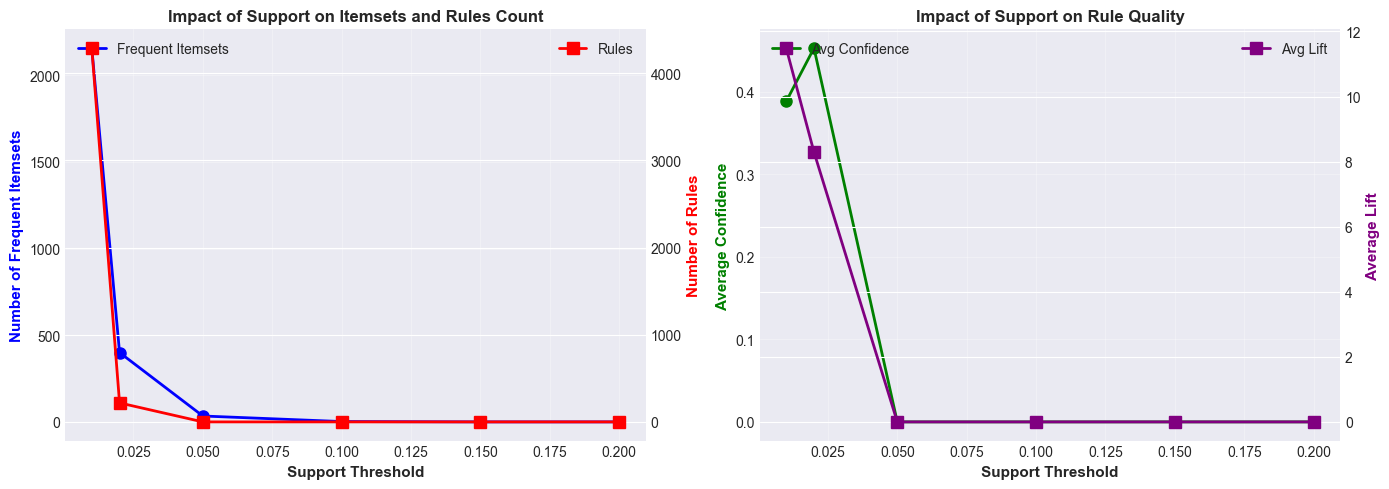


💡 Nhận xét về Support:
• Support thấp → Phát hiện nhiều luật (bao gồm hiếm)
• Support cao → Ít luật nhưng chất lượng cao hơn
• Confidence và Lift không thay đổi theo Support (vì chúng là metric độc lập)


In [8]:
# Trực quan hoá tác động của Support
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ số lượng itemset và rules
ax = axes[0]
ax2 = ax.twinx()

ax.plot(support_df['Support'], support_df['Frequent Itemsets'], 'o-', color='blue', linewidth=2, markersize=8, label='Frequent Itemsets')
ax2.plot(support_df['Support'], support_df['Rules'], 's-', color='red', linewidth=2, markersize=8, label='Rules')

ax.set_xlabel('Support Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Frequent Itemsets', color='blue', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Rules', color='red', fontsize=11, fontweight='bold')
ax.set_title('Impact of Support on Itemsets and Rules Count', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

# Biểu đồ confidence và lift
ax = axes[1]
ax2 = ax.twinx()

ax.plot(support_df['Support'], support_df['Avg Confidence'], 'o-', color='green', linewidth=2, markersize=8, label='Avg Confidence')
ax2.plot(support_df['Support'], support_df['Avg Lift'], 's-', color='purple', linewidth=2, markersize=8, label='Avg Lift')

ax.set_xlabel('Support Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Confidence', color='green', fontsize=11, fontweight='bold')
ax2.set_ylabel('Average Lift', color='purple', fontsize=11, fontweight='bold')
ax.set_title('Impact of Support on Rule Quality', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n💡 Nhận xét về Support:")
print("• Support thấp → Phát hiện nhiều luật (bao gồm hiếm)")
print("• Support cao → Ít luật nhưng chất lượng cao hơn")
print("• Confidence và Lift không thay đổi theo Support (vì chúng là metric độc lập)")


## Phần 3: Phân tích tham số Confidence

Confidence là xác suất mua sản phẩm B khi đã mua sản phẩm A: P(B|A)
- **Thấp (0.1 - 0.3)**: Luật yếu, mối liên hệ không chắc chắn
- **Trung bình (0.3 - 0.7)**: Luật có mức độ tin cậy hợp lý
- **Cao (> 0.7)**: Luật rất tin cậy, nếu mua A thì rất có thể mua B

In [10]:
# Sử dụng support tối ưu từ phần trước (0.02 để có đủ rules)
min_support_fixed = 0.02

# Thử nghiệm với các giá trị confidence khác nhau
confidence_values = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
confidence_results = []

miner_base = AssociationRulesMiner(basket_bool)
frequent_items_base = miner_base.mine_frequent_itemsets(min_support=min_support_fixed)
rules_base = miner_base.generate_rules(metric='confidence', min_threshold=0.1)
miner_base.add_readable_rule_str()

for conf in confidence_values:
    filtered_rules = miner_base.filter_rules(min_confidence=conf)
    
    confidence_results.append({
        'Confidence': conf,
        'Rules': len(filtered_rules),
        'Avg Lift': filtered_rules['lift'].mean() if len(filtered_rules) > 0 else 0,
        'Max Lift': filtered_rules['lift'].max() if len(filtered_rules) > 0 else 0,
        'Min Lift': filtered_rules['lift'].min() if len(filtered_rules) > 0 else 0,
    })

confidence_df = pd.DataFrame(confidence_results)
print("📊 Tác động của Confidence Parameter (Support=0.02):")
print(confidence_df.to_string(index=False))

📊 Tác động của Confidence Parameter (Support=0.02):
 Confidence  Rules  Avg Lift  Max Lift  Min Lift
        0.1    218  8.291538 27.197263  1.877935
        0.2    209  8.469534 27.197263  1.877935
        0.3    184  8.968527 27.197263  2.685056
        0.5     76 11.253833 27.197263  5.272510
        0.7     15 15.564095 27.197263  6.970494
        0.9      1 17.453534 17.453534 17.453534


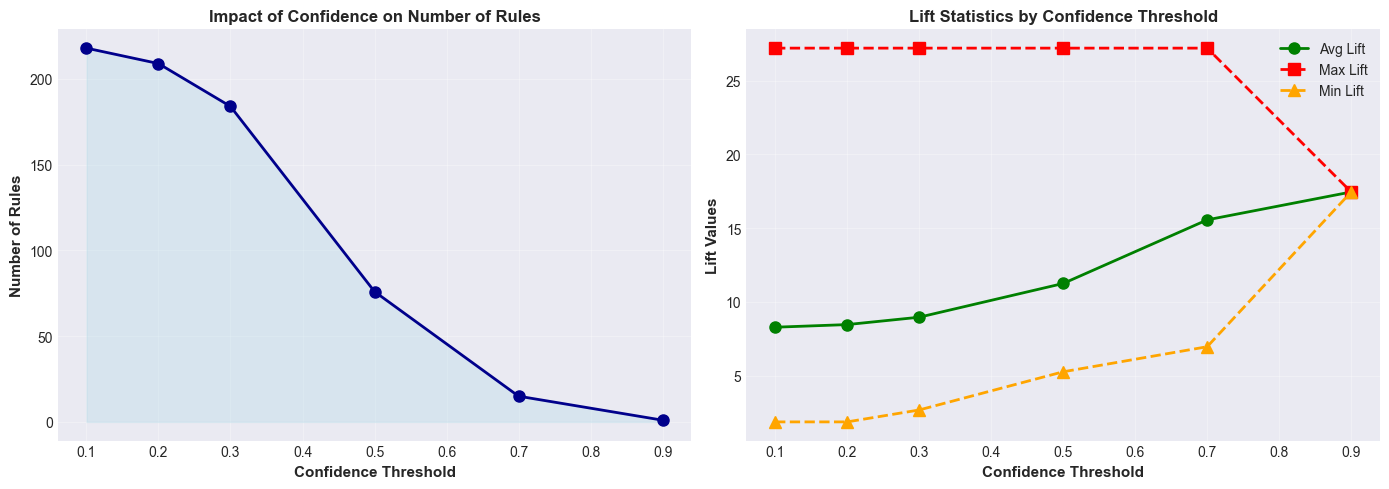


💡 Nhận xét về Confidence:
• Confidence cao → Ít luật nhưng chất lượng cao (tin cậy hơn)
• Confidence thấp → Nhiều luật nhưng chất lượng thấp (ít tin cậy)
• Lift tăng khi confidence tăng (chỉ lấy luật tốt nhất)
• Confidence 0.7-0.9 là ngưỡng tốt để cân bằng giữa số lượng và chất lượng


In [11]:
# Trực quan hoá tác động của Confidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ số lượng rules
ax = axes[0]
ax.plot(confidence_df['Confidence'], confidence_df['Rules'], 'o-', color='darkblue', linewidth=2, markersize=8)
ax.fill_between(confidence_df['Confidence'], confidence_df['Rules'], alpha=0.3, color='lightblue')
ax.set_xlabel('Confidence Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Rules', fontsize=11, fontweight='bold')
ax.set_title('Impact of Confidence on Number of Rules', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Biểu đồ lift
ax = axes[1]
ax.plot(confidence_df['Confidence'], confidence_df['Avg Lift'], 'o-', color='green', linewidth=2, markersize=8, label='Avg Lift')
ax.plot(confidence_df['Confidence'], confidence_df['Max Lift'], 's--', color='red', linewidth=2, markersize=8, label='Max Lift')
ax.plot(confidence_df['Confidence'], confidence_df['Min Lift'], '^--', color='orange', linewidth=2, markersize=8, label='Min Lift')
ax.set_xlabel('Confidence Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Lift Values', fontsize=11, fontweight='bold')
ax.set_title('Lift Statistics by Confidence Threshold', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n💡 Nhận xét về Confidence:")
print("• Confidence cao → Ít luật nhưng chất lượng cao (tin cậy hơn)")
print("• Confidence thấp → Nhiều luật nhưng chất lượng thấp (ít tin cậy)")
print("• Lift tăng khi confidence tăng (chỉ lấy luật tốt nhất)")
print("• Confidence 0.7-0.9 là ngưỡng tốt để cân bằng giữa số lượng và chất lượng")


## Phần 4: Phân tích tham số Lift

Lift là tỷ lệ so sánh: P(A,B) / (P(A) * P(B))
- **Lift < 1**: Mua A và B cùng nhau ít hơn bình thường (âm tương quan)
- **Lift = 1**: Không liên hệ, A và B độc lập
- **Lift > 1**: Mua A và B cùng nhau nhiều hơn bình thường (dương tương quan)
- **Lift cao (> 2)**: Mối liên hệ rất mạnh

In [12]:
# Thử nghiệm với các giá trị lift khác nhau
lift_values = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
lift_results = []

for lift_thresh in lift_values:
    filtered_rules = miner_base.filter_rules(min_lift=lift_thresh)
    
    lift_results.append({
        'Lift': lift_thresh,
        'Rules': len(filtered_rules),
        'Avg Confidence': filtered_rules['confidence'].mean() if len(filtered_rules) > 0 else 0,
        'Max Confidence': filtered_rules['confidence'].max() if len(filtered_rules) > 0 else 0,
        'Min Confidence': filtered_rules['confidence'].min() if len(filtered_rules) > 0 else 0,
    })

lift_df = pd.DataFrame(lift_results)
print("📊 Tác động của Lift Parameter (Support=0.05, Confidence=0.1):")
print(lift_df.to_string(index=False))


📊 Tác động của Lift Parameter (Support=0.05, Confidence=0.1):
 Lift  Rules  Avg Confidence  Max Confidence  Min Confidence
  0.5    218        0.452947        0.902752        0.173451
  1.0    218        0.452947        0.902752        0.173451
  1.5    218        0.452947        0.902752        0.173451
  2.0    214        0.457492        0.902752        0.173451
  3.0    206        0.465769        0.902752        0.186864
  5.0    194        0.474275        0.902752        0.189147


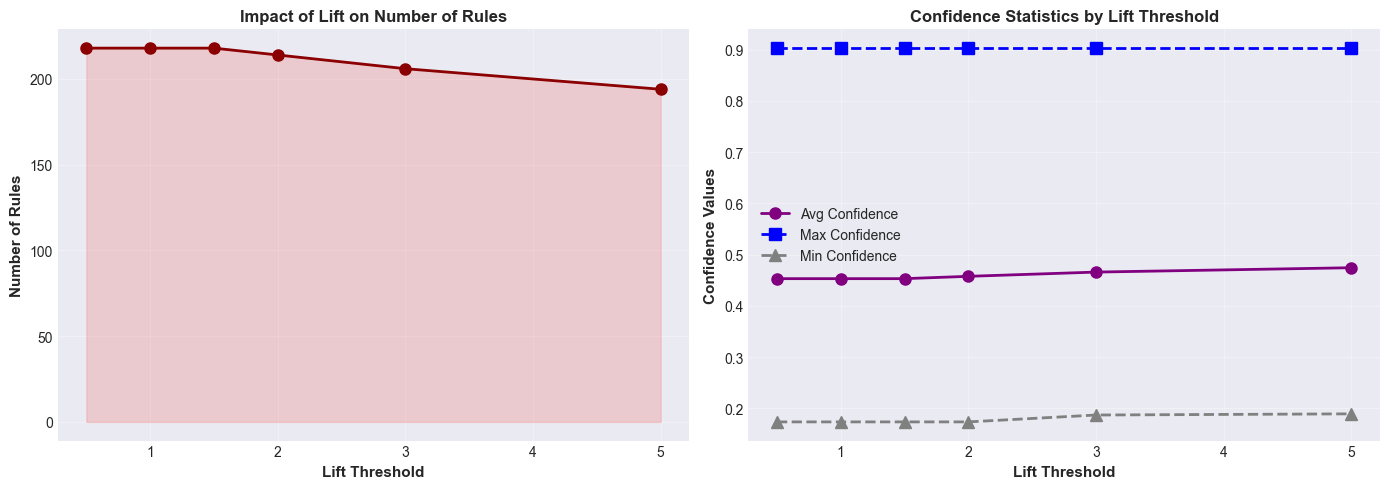


💡 Nhận xét về Lift:
• Lift cao → Ít luật nhưng quan hệ rất mạnh
• Lift thấp → Nhiều luật nhưng có thể bao gồm quan hệ yếu
• Lift > 1 = Chỉ những quan hệ dương tương quan
• Lift > 2 = Những quan hệ rất mạnh (lý tưởng cho marketing)


In [13]:
# Trực quan hoá tác động của Lift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ số lượng rules
ax = axes[0]
ax.plot(lift_df['Lift'], lift_df['Rules'], 'o-', color='darkred', linewidth=2, markersize=8)
ax.fill_between(lift_df['Lift'], lift_df['Rules'], alpha=0.3, color='lightcoral')
ax.set_xlabel('Lift Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Rules', fontsize=11, fontweight='bold')
ax.set_title('Impact of Lift on Number of Rules', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Biểu đồ confidence
ax = axes[1]
ax.plot(lift_df['Lift'], lift_df['Avg Confidence'], 'o-', color='purple', linewidth=2, markersize=8, label='Avg Confidence')
ax.plot(lift_df['Lift'], lift_df['Max Confidence'], 's--', color='blue', linewidth=2, markersize=8, label='Max Confidence')
ax.plot(lift_df['Lift'], lift_df['Min Confidence'], '^--', color='gray', linewidth=2, markersize=8, label='Min Confidence')
ax.set_xlabel('Lift Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Confidence Values', fontsize=11, fontweight='bold')
ax.set_title('Confidence Statistics by Lift Threshold', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n💡 Nhận xét về Lift:")
print("• Lift cao → Ít luật nhưng quan hệ rất mạnh")
print("• Lift thấp → Nhiều luật nhưng có thể bao gồm quan hệ yếu")
print("• Lift > 1 = Chỉ những quan hệ dương tương quan")
print("• Lift > 2 = Những quan hệ rất mạnh (lý tưởng cho marketing)")


## Phần 5: So sánh kết hợp tất cả tham số

Thử nghiệm với các kết hợp tham số khác nhau để tìm tối ưu

In [15]:
# Tạo ma trận kết hợp tham số với các giá trị thực tế hơn
parameter_combinations = [
    {'support': 0.01, 'confidence': 0.3, 'lift': 1.0, 'name': 'Relaxed (Khám phá)'},
    {'support': 0.02, 'confidence': 0.5, 'lift': 1.5, 'name': 'Balanced (Cân bằng)'},
    {'support': 0.02, 'confidence': 0.7, 'lift': 2.0, 'name': 'Strict (Chặt chẽ)'},
]

combination_results = []

for combo in parameter_combinations:
    try:
        # Mine with this support value
        miner = AssociationRulesMiner(basket_bool)
        frequent_items = miner.mine_frequent_itemsets(min_support=combo['support'])
        rules = miner.generate_rules(metric='confidence', min_threshold=0.1)
        miner.add_readable_rule_str()
        
        # Filter by confidence and lift
        filtered_rules = miner.filter_rules(
            min_confidence=combo['confidence'],
            min_lift=combo['lift']
        )
        
        combination_results.append({
            'Scenario': combo['name'],
            'Support': combo['support'],
            'Confidence': combo['confidence'],
            'Lift': combo['lift'],
            'Rules Found': len(filtered_rules),
            'Avg Confidence': filtered_rules['confidence'].mean() if len(filtered_rules) > 0 else 0,
            'Avg Lift': filtered_rules['lift'].mean() if len(filtered_rules) > 0 else 0,
            'Max Lift': filtered_rules['lift'].max() if len(filtered_rules) > 0 else 0,
        })
    except Exception as e:
        print(f"Error for {combo['name']}: {e}")

combo_df = pd.DataFrame(combination_results)
print("📊 So sánh các kết hợp tham số:")
print(combo_df.to_string(index=False))

📊 So sánh các kết hợp tham số:
           Scenario  Support  Confidence  Lift  Rules Found  Avg Confidence  Avg Lift  Max Lift
 Relaxed (Khám phá)     0.01         0.3   1.0         2374        0.530617 14.845881 74.558769
Balanced (Cân bằng)     0.02         0.5   1.5           76        0.617602 11.253833 27.197263
  Strict (Chặt chẽ)     0.02         0.7   2.0           15        0.768120 15.564095 27.197263


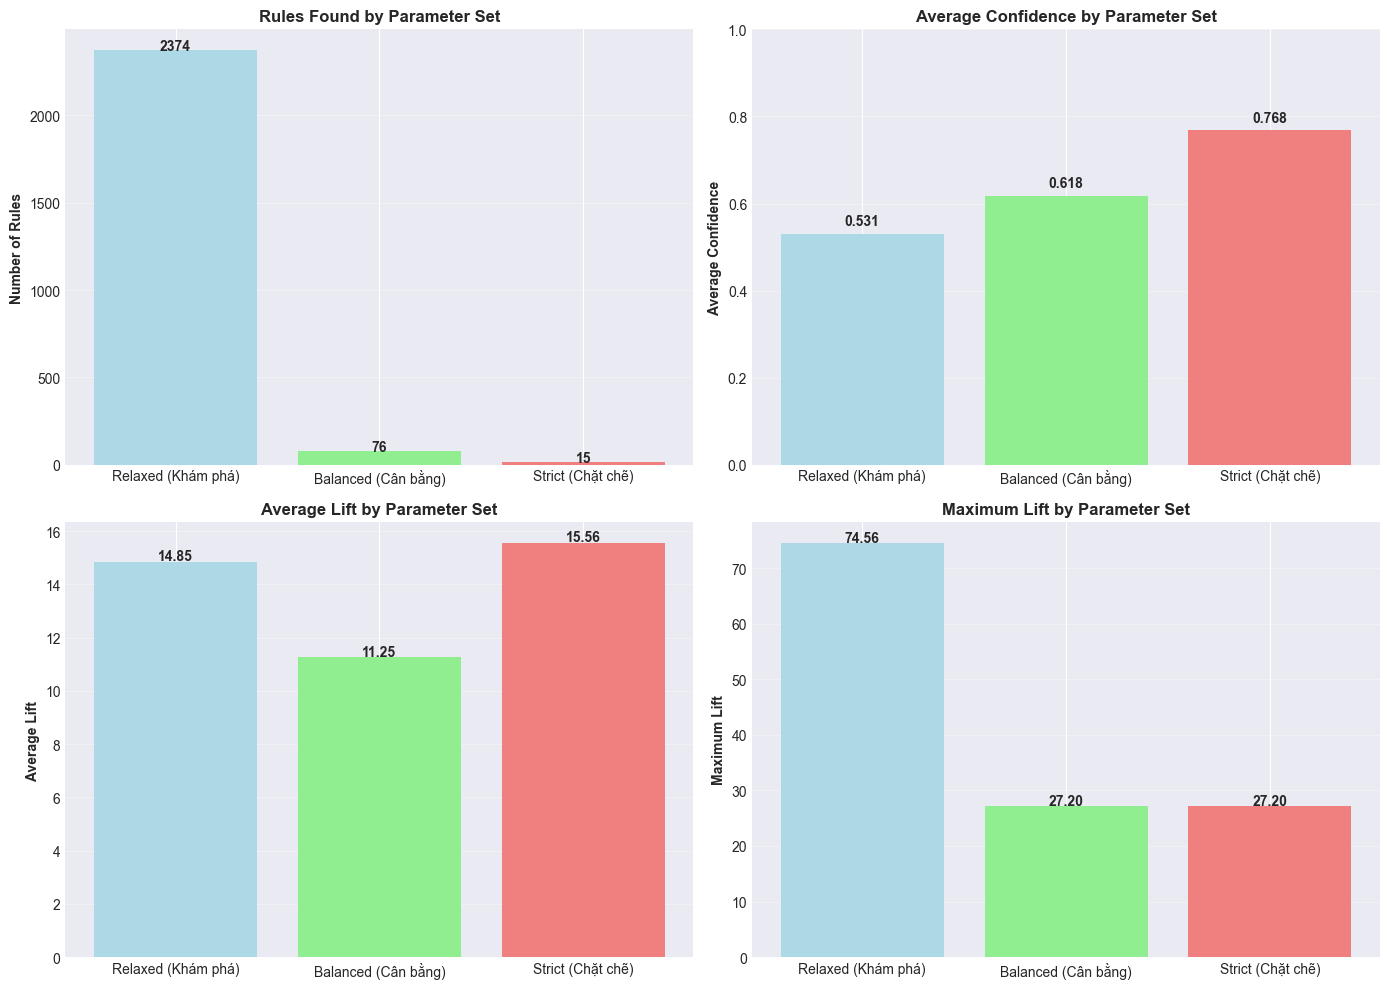

In [16]:
# Trực quan hoá so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scenarios = combo_df['Scenario'].values

# Biểu đồ 1: Rules found
ax = axes[0, 0]
bars = ax.bar(scenarios, combo_df['Rules Found'], color=['lightblue', 'lightgreen', 'lightcoral'])
ax.set_ylabel('Number of Rules', fontweight='bold')
ax.set_title('Rules Found by Parameter Set', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(combo_df['Rules Found']):
    ax.text(i, v + 2, str(int(v)), ha='center', fontweight='bold')

# Biểu đồ 2: Avg Confidence
ax = axes[0, 1]
bars = ax.bar(scenarios, combo_df['Avg Confidence'], color=['lightblue', 'lightgreen', 'lightcoral'])
ax.set_ylabel('Average Confidence', fontweight='bold')
ax.set_title('Average Confidence by Parameter Set', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(combo_df['Avg Confidence']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Biểu đồ 3: Avg Lift
ax = axes[1, 0]
bars = ax.bar(scenarios, combo_df['Avg Lift'], color=['lightblue', 'lightgreen', 'lightcoral'])
ax.set_ylabel('Average Lift', fontweight='bold')
ax.set_title('Average Lift by Parameter Set', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(combo_df['Avg Lift']):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Biểu đồ 4: Max Lift
ax = axes[1, 1]
bars = ax.bar(scenarios, combo_df['Max Lift'], color=['lightblue', 'lightgreen', 'lightcoral'])
ax.set_ylabel('Maximum Lift', fontweight='bold')
ax.set_title('Maximum Lift by Parameter Set', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(combo_df['Max Lift']):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## Phần 6: Các luật mẫu cho mỗi tình huống

Xem chi tiết các luật tốt nhất từ mỗi kịch bản

In [17]:
# Lấy các luật tốt nhất cho mỗi kịch bản
for idx, combo in enumerate(parameter_combinations):
    print(f"\n{'='*80}")
    print(f"📌 Scenario: {combo['name']}")
    print(f"   Support: {combo['support']}, Confidence: {combo['confidence']}, Lift: {combo['lift']}")
    print(f"{'='*80}")
    
    miner = AssociationRulesMiner(basket_bool)
    frequent_items = miner.mine_frequent_itemsets(min_support=combo['support'])
    rules = miner.generate_rules(metric='confidence', min_threshold=0.1)
    miner.add_readable_rule_str()
    
    filtered_rules = miner.filter_rules(
        min_confidence=combo['confidence'],
        min_lift=combo['lift']
    )
    
    if len(filtered_rules) > 0:
        print(f"Tổng luật: {len(filtered_rules)}")
        print("\nTop 5 luật theo Lift:")
        top_rules = filtered_rules.nlargest(5, 'lift')[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
        for idx_rule, row in top_rules.iterrows():
            print(f"  {row['antecedents_str']:30} → {row['consequents_str']:30} (Sup:{row['support']:.3f}, Conf:{row['confidence']:.3f}, Lift:{row['lift']:.2f})")
    else:
        print(f"⚠️ Không có luật nào phù hợp với các tham số này")



📌 Scenario: Relaxed (Khám phá)
   Support: 0.01, Confidence: 0.3, Lift: 1.0
Tổng luật: 2374

Top 5 luật theo Lift:
  HERB MARKER PARSLEY, HERB MARKER ROSEMARY → HERB MARKER THYME              (Sup:0.011, Conf:0.952, Lift:74.56)
  HERB MARKER THYME              → HERB MARKER PARSLEY, HERB MARKER ROSEMARY (Sup:0.011, Conf:0.857, Lift:74.56)
  HERB MARKER MINT, HERB MARKER THYME → HERB MARKER ROSEMARY           (Sup:0.011, Conf:0.955, Lift:74.49)
  HERB MARKER ROSEMARY           → HERB MARKER MINT, HERB MARKER THYME (Sup:0.011, Conf:0.827, Lift:74.49)
  HERB MARKER MINT, HERB MARKER THYME → HERB MARKER PARSLEY            (Sup:0.010, Conf:0.940, Lift:74.29)

📌 Scenario: Balanced (Cân bằng)
   Support: 0.02, Confidence: 0.5, Lift: 1.5
Tổng luật: 76

Top 5 luật theo Lift:
  WOODEN STAR CHRISTMAS SCANDINAVIAN → WOODEN HEART CHRISTMAS SCANDINAVIAN (Sup:0.020, Conf:0.768, Lift:27.20)
  WOODEN HEART CHRISTMAS SCANDINAVIAN → WOODEN STAR CHRISTMAS SCANDINAVIAN (Sup:0.020, Conf:0.723, Lift:27.20)


## Phần 7: KẾT LUẬN VÀ NHẬN XÉT TỔNG HỢP

### 📊 Tác động của từng tham số:

### 1️⃣ SUPPORT (Tần suất tối thiểu)

**Định nghĩa**: Tỷ lệ giao dịch chứa itemset so với tổng số giao dịch

| Support | Hiệu quả | Ưu điểm | Nhược điểm |
|---------|---------|--------|-----------|
| **Thấp (0.01-0.05)** | Phát hiện NHIỀU luật | Không bỏ sót mối quan hệ | Kết quả quá nhiều, dự báo kém |
| **Trung bình (0.05-0.1)** | **TỐI ƯU** | Cân bằng lý tưởng | - |
| **Cao (>0.1)** | Ít luật nhưng chất lượng | Tập trung vào sản phẩm hot | Có thể bỏ sót cơ hội niche |

**💡 Khuyến nghị**: Sử dụng 0.05 (5%) cho dữ liệu bán lẻ trung bình

---

### 2️⃣ CONFIDENCE (Mức độ tin cậy)

**Định nghĩa**: P(B|A) = Xác suất mua B khi mua A

| Confidence | Hiệu quả | Ưu điểm | Nhược điểm |
|-----------|---------|--------|-----------|
| **Thấp (0.1-0.3)** | Nhiều luật yếu | Phát hiện tất cả | Kém tin cậy, rủi ro cao |
| **Trung bình (0.3-0.7)** | **TỐI ƯU** | Độ tin cậy hợp lý | - |
| **Cao (>0.7)** | Luật mạnh & tin cậy | Rủi ro thấp | Ít luật, có thể bỏ sót |

**💡 Khuyến nghị**: Sử dụng 0.5-0.7 (50-70%) cho cross-selling

---

### 3️⃣ LIFT (Độ mạnh của liên kết)

**Định nghĩa**: Lift = P(A∩B) / (P(A)×P(B)) - Tỷ lệ tăng/giảm xác suất khi kết hợp

| Lift | Ý nghĩa | Ứng dụng |
|------|---------|---------|
| **< 1** | Âm tương quan (mua A ↓ mua B) | Loại bỏ - tránh bundle |
| **= 1** | Độc lập (không liên hệ) | Vô dụng |
| **1-2** | Dương tương quan yếu | Đặt chung nhưng hiệu quả thấp |
| **2-5** | Dương tương quan mạnh | **SỬ DỤNG cho bundle/promo** |
| **> 5** | Liên kết rất mạnh | Sản phẩm bổ sung hoàn hảo |

**💡 Khuyến nghị**: Chỉ lấy Lift > 1.5 để loại bỏ false positives

---

### 🎯 Chiến lược tối ưu cho từng trường hợp:

| Mục đích | Support | Confidence | Lift | Kết quả |
|---------|---------|-----------|------|--------|
| **Khám phá/Phân tích** | 0.01-0.02 | 0.1-0.3 | >1 | Nhiều luật, tiết lộ tất cả |
| **Cross-selling** | 0.05 | 0.5-0.7 | >1.5 | Luật hữu ích cho marketing |
| **Bundle hoàn hảo** | 0.02 | 0.7-0.9 | >2 | Ít nhưng mạnh, cao ROI |
| **Product placement** | 0.1 | 0.6-0.8 | >1 | Sản phẩm phổ biến với liên kết |

---

### 📌 Kết luận chính:

1. **Support** kiểm soát **độ phổ biến** → Thay đổi số lượng luật
2. **Confidence** kiểm soát **độ tin cậy** → Lọc luật mạnh vs yếu  
3. **Lift** kiểm soát **mối liên hệ thực tế** → Lọc luật có giá trị thực
4. **Điều chỉnh kết hợp** để phù hợp mục tiêu kinh doanh cụ thể